In [ ]:
import polars
import altair
import matplotlib.pyplot as plt

In [ ]:
import marimo as mo

# 第 1 章: ウェブからの注文数を分析する 10 本ノック

## ノック 1: データを読み込んでみよう

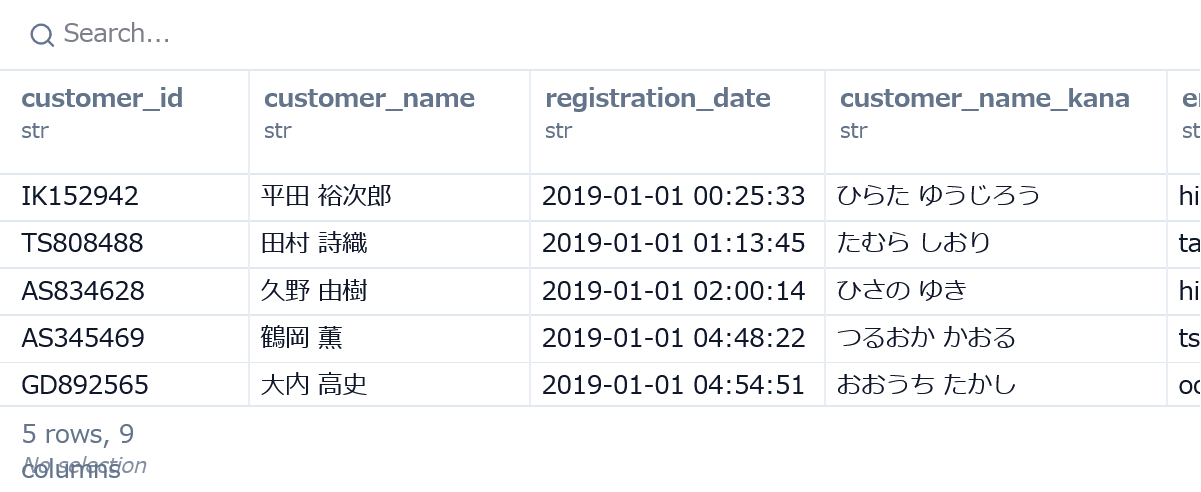

In [ ]:
customer_master = polars.read_csv("./data/1章/customer_master.csv")
customer_master.head()

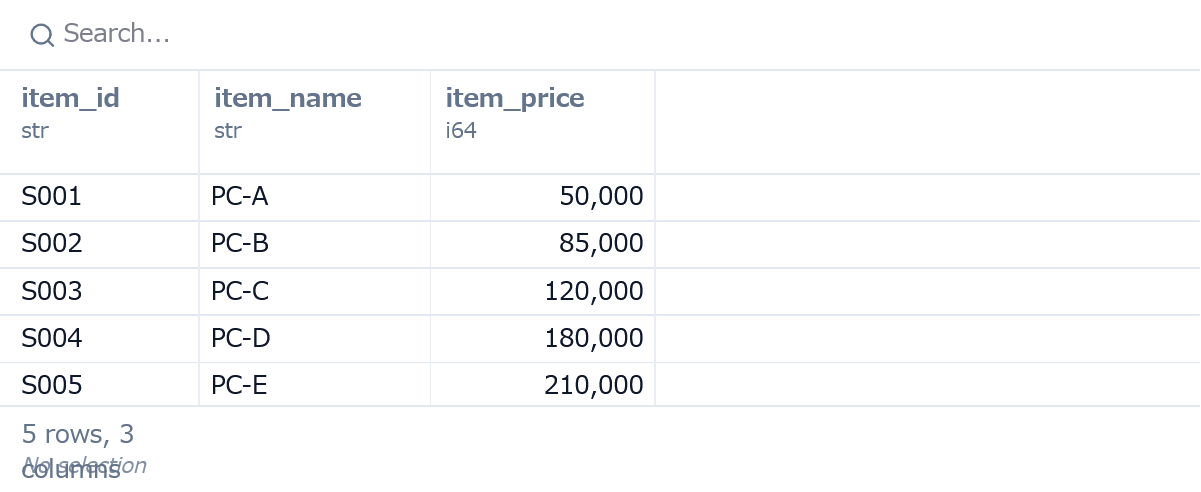

In [ ]:
item_master = polars.read_csv("./data/1章/item_master.csv")
item_master.head()

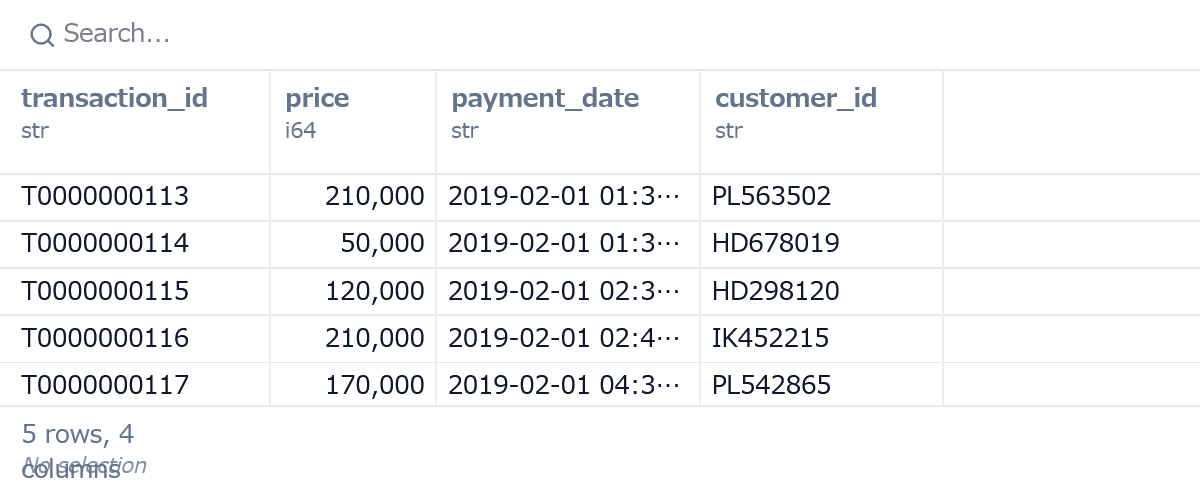

In [ ]:
transaction_1 = polars.read_csv("./data/1章/transaction_1.csv")
transaction_1.head()

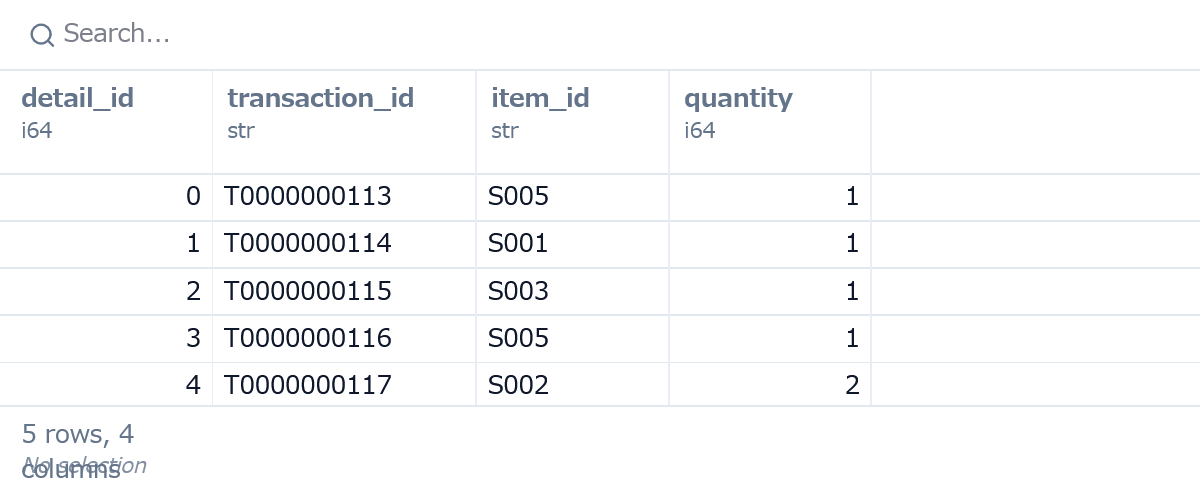

In [ ]:
transaction_detail_1 = polars.read_csv("./data/1章/transaction_detail_1.csv")
transaction_detail_1.head()

## ノック 2: データを結合 (ユニオン) してみよう

len(transaction_1)=5000
len(transaction_2)=1786
len(transaction)=6786


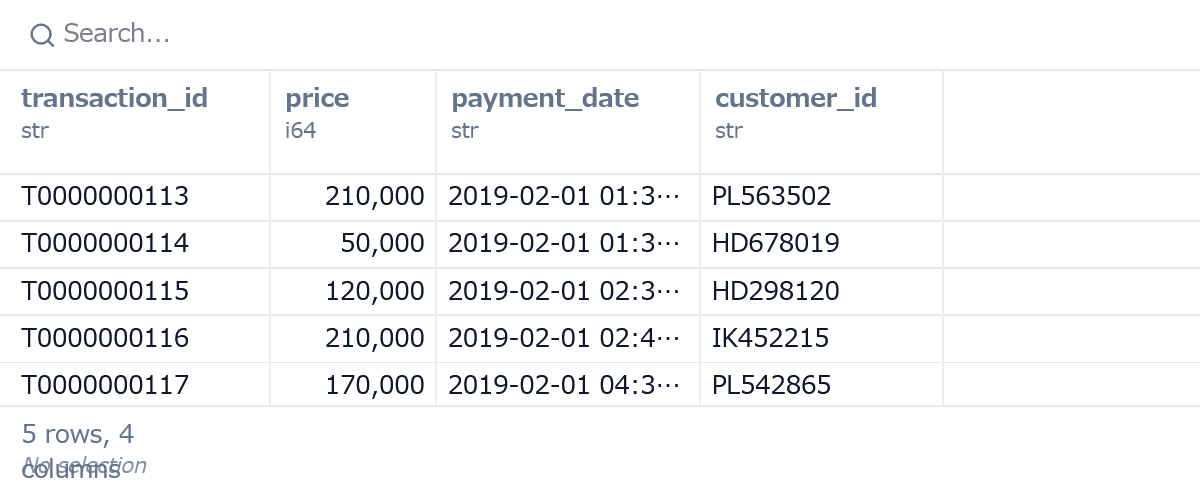

In [ ]:
transaction_2 = polars.read_csv("./data/1章/transaction_2.csv")
transaction = polars.concat([transaction_1, transaction_2])

print(f"{len(transaction_1)=}")
print(f"{len(transaction_2)=}")
print(f"{len(transaction)=}")

transaction.head()

len(transaction_detail_1)=5000
len(transaction_detail_2)=2144
len(transaction_detail)=7144


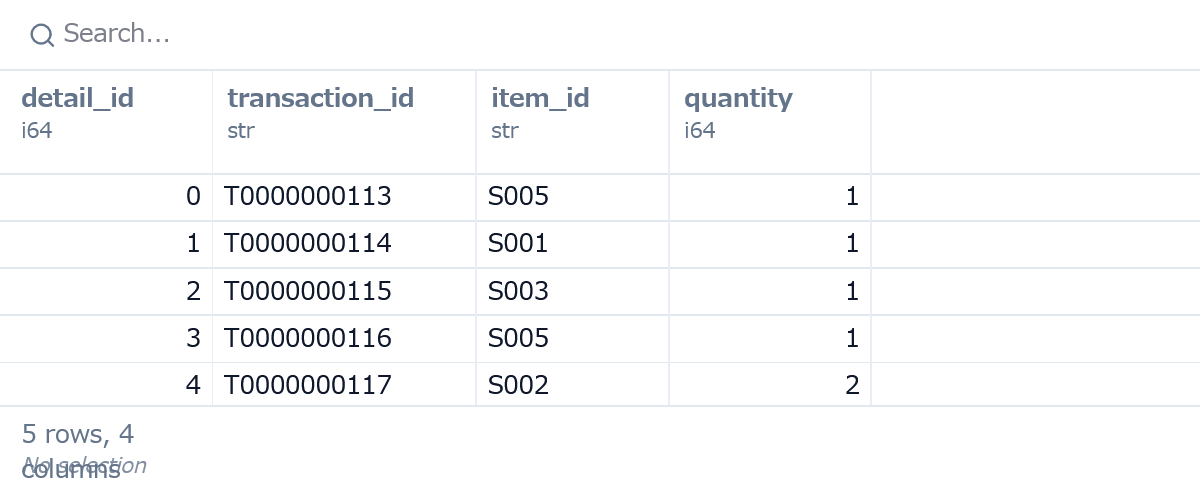

In [ ]:
transaction_detail_2 = polars.read_csv("./data/1章/transaction_detail_2.csv")
transaction_detail = polars.concat([transaction_detail_1, transaction_detail_2])

print(f"{len(transaction_detail_1)=}")
print(f"{len(transaction_detail_2)=}")
print(f"{len(transaction_detail)=}")

transaction_detail.head()

## ノック 3: 売上データ同士を結合 (ジョイン) してみよう

len(transaction_detail)=7144
len(transaction)=6786
len(join_data1)=7144


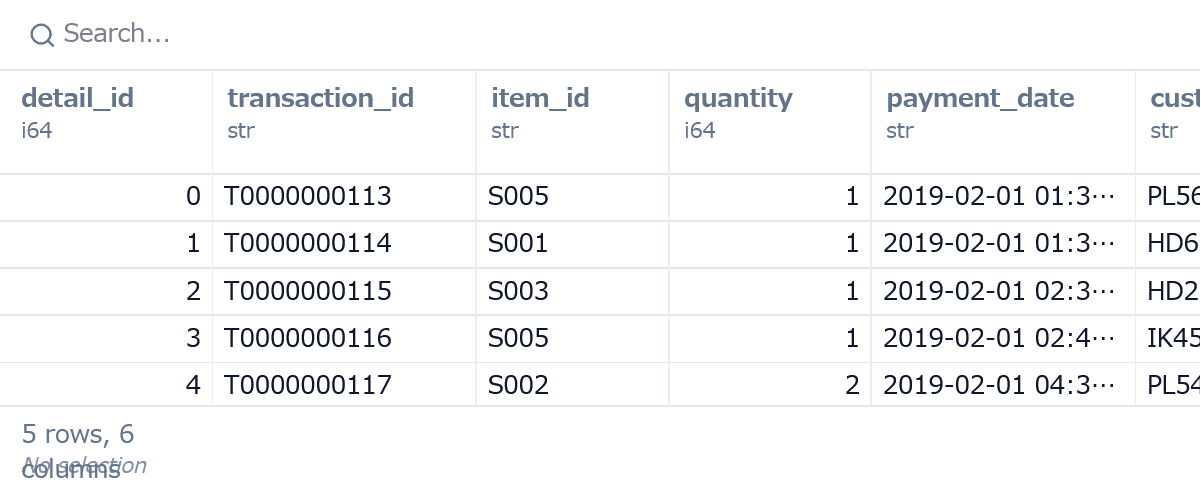

In [ ]:
join_data1 = transaction_detail.join(
    transaction[["transaction_id", "payment_date", "customer_id"]],
    on="transaction_id",
    how="left",
)

print(f"{len(transaction_detail)=}")
print(f"{len(transaction)=}")
print(f"{len(join_data1)=}")

join_data1.head()

## ノック 4: マスターデータを結合 (ジョイン) してみよう

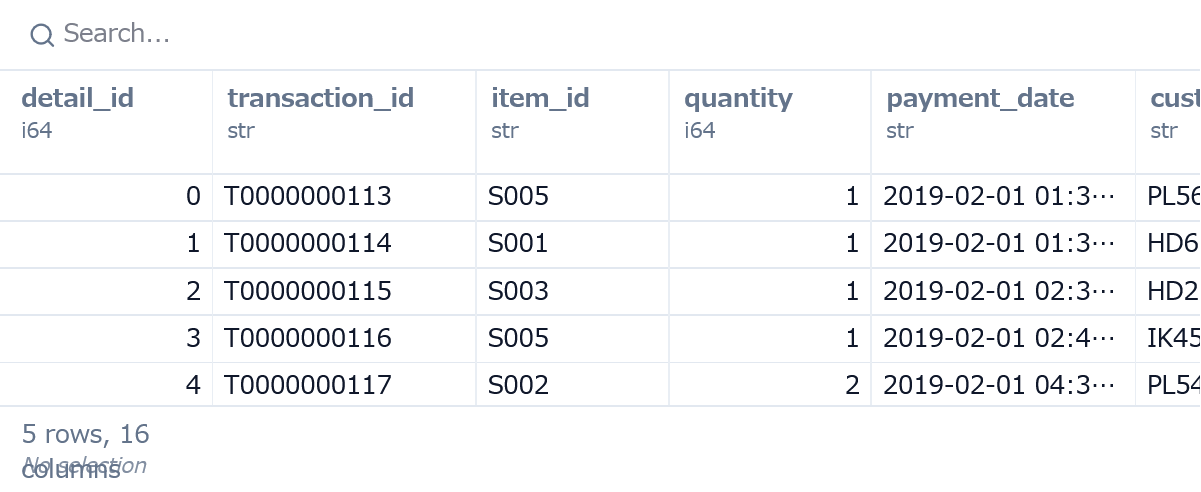

In [ ]:
join_data2 = join_data1.join(customer_master, on="customer_id", how="left").join(
    item_master, on="item_id", how="left"
)

join_data2.head()

## ノック 5: 必要なデータ列を作ろう

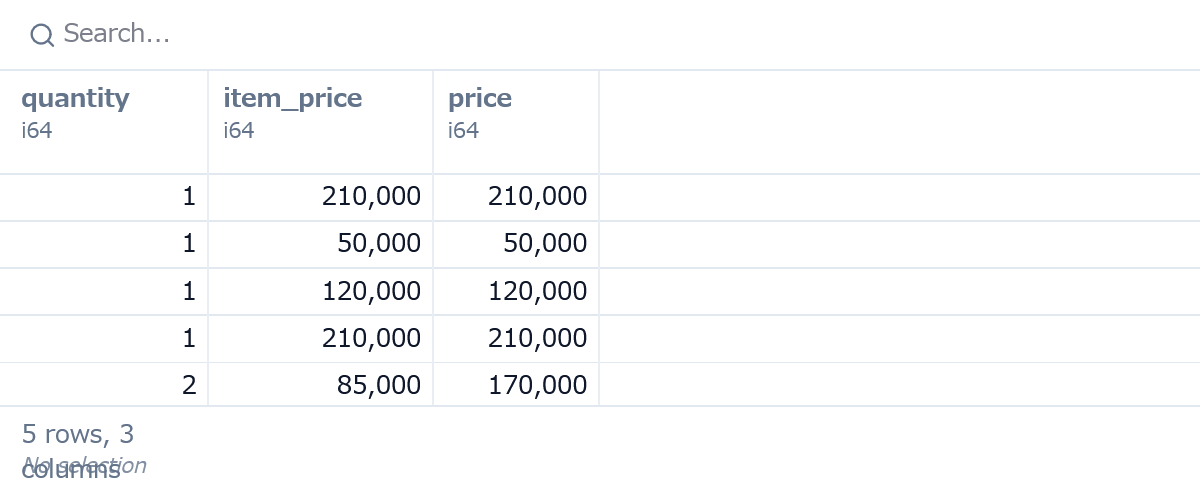

In [ ]:
join_data3 = join_data2.with_columns(
    (polars.col("quantity") * polars.col("item_price")).alias("price")
)

join_data3.select(["quantity", "item_price", "price"]).head()

## ノック 6: データ検算をしよう

In [ ]:
print(f"{join_data3["price"].sum()=}")
print(f"{transaction["price"].sum()=}")
assert join_data3["price"].sum() == transaction["price"].sum()

join_data3["price"].sum()=971135000
transaction["price"].sum()=971135000


## ノック 7: 各種統計量を把握しよう

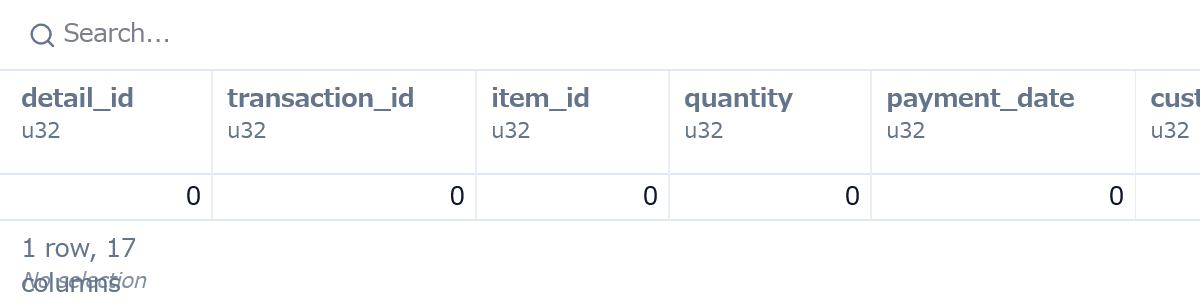

In [ ]:
join_data3.null_count()

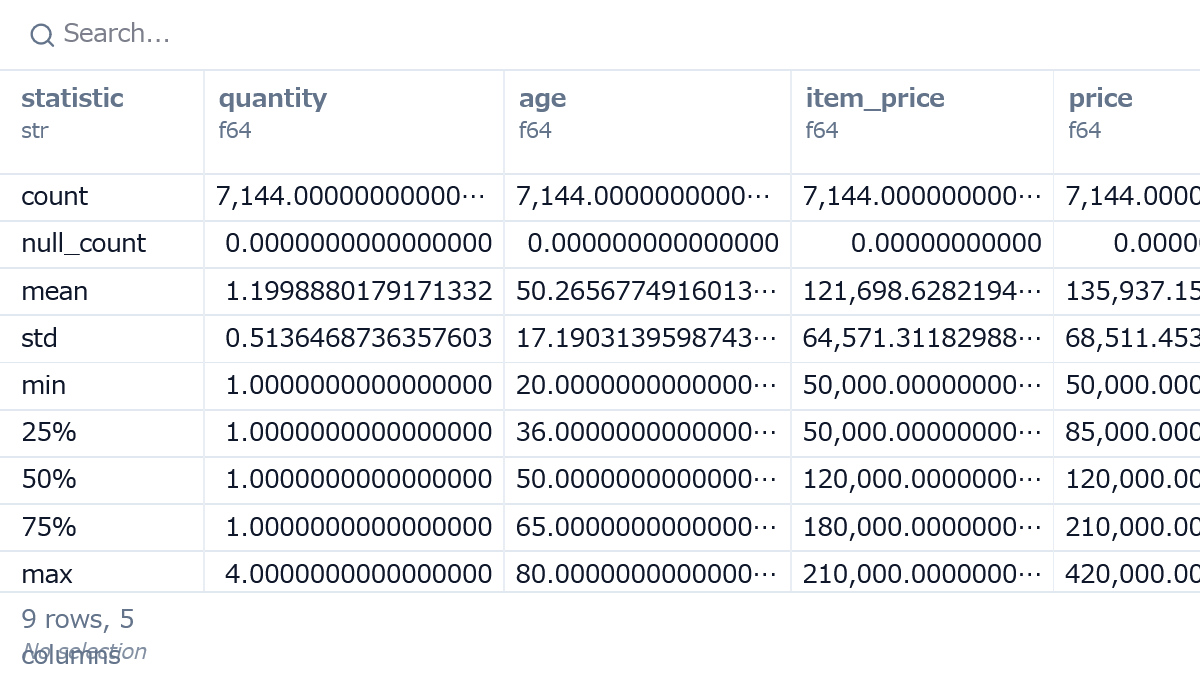

In [ ]:
join_data3.select(["quantity", "age", "item_price", "price"]).describe()

In [ ]:
print(f"{join_data3['payment_date'].min()=}")
print(f"{join_data3['payment_date'].max()=}")

join_data3['payment_date'].min()='2019-02-01 01:36:57'
join_data3['payment_date'].max()='2019-07-31 23:41:38'


## ノック 8: 月別でデータを集計してみよう

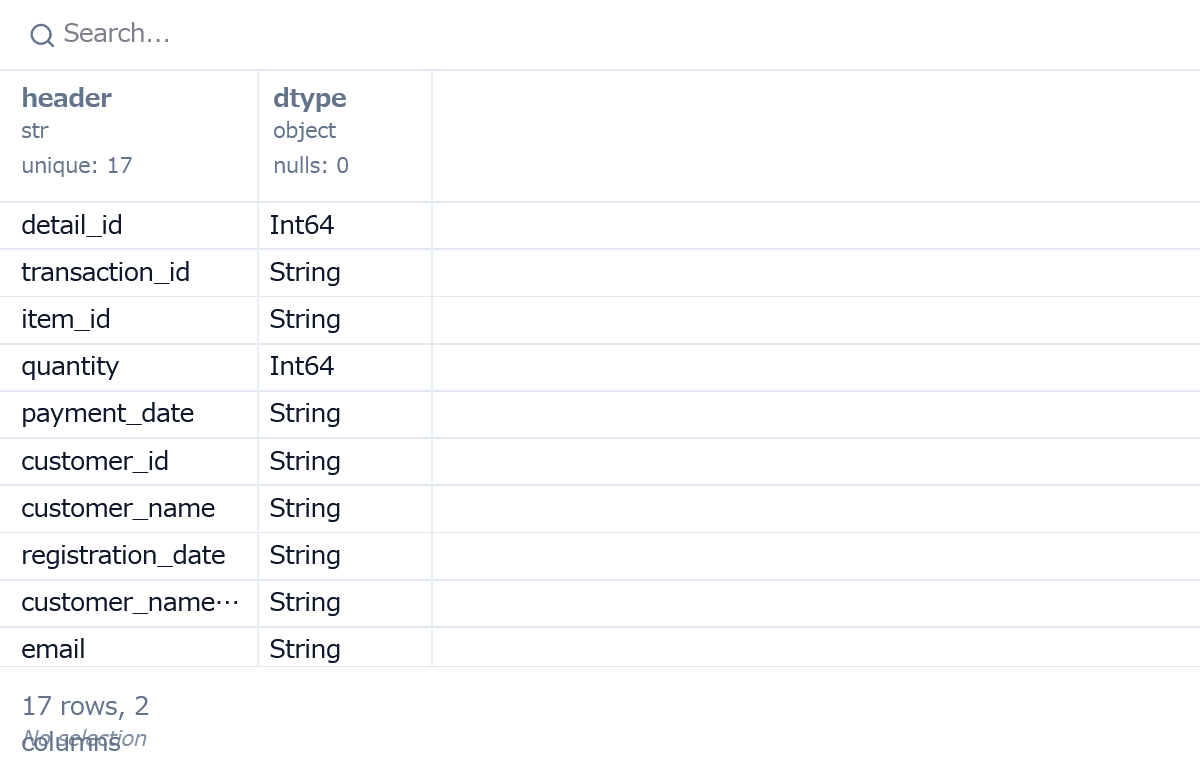

In [ ]:
polars.DataFrame(
    {
        "header": join_data3.columns,
        "dtype": join_data3.dtypes,
    }
)

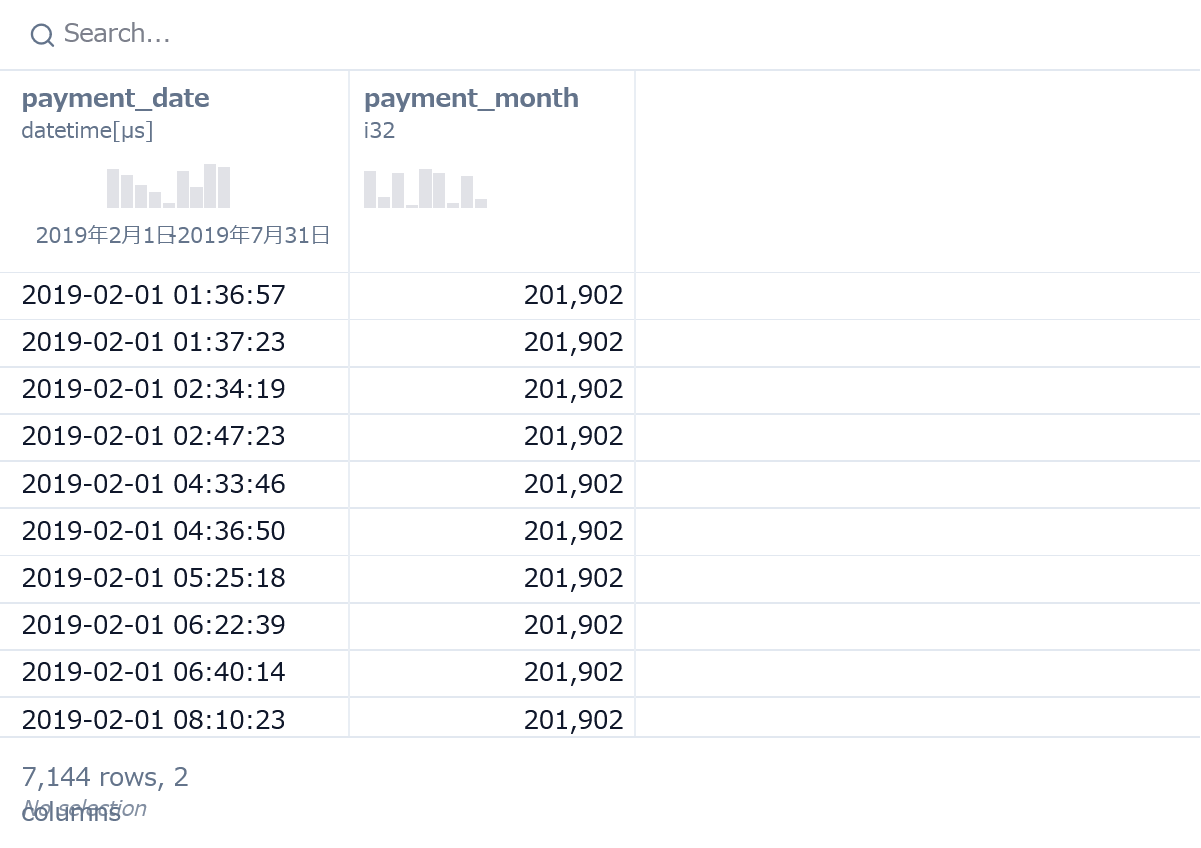

In [ ]:
join_data4 = join_data3.with_columns(
    polars.col("payment_date").str.to_datetime().alias("payment_date")
)
join_data5 = join_data4.with_columns(
    (
        polars.col("payment_date").dt.year() * 100
        + polars.col("payment_date").dt.month()
    ).alias("payment_month")
)

join_data5.select(["payment_date", "payment_month"])

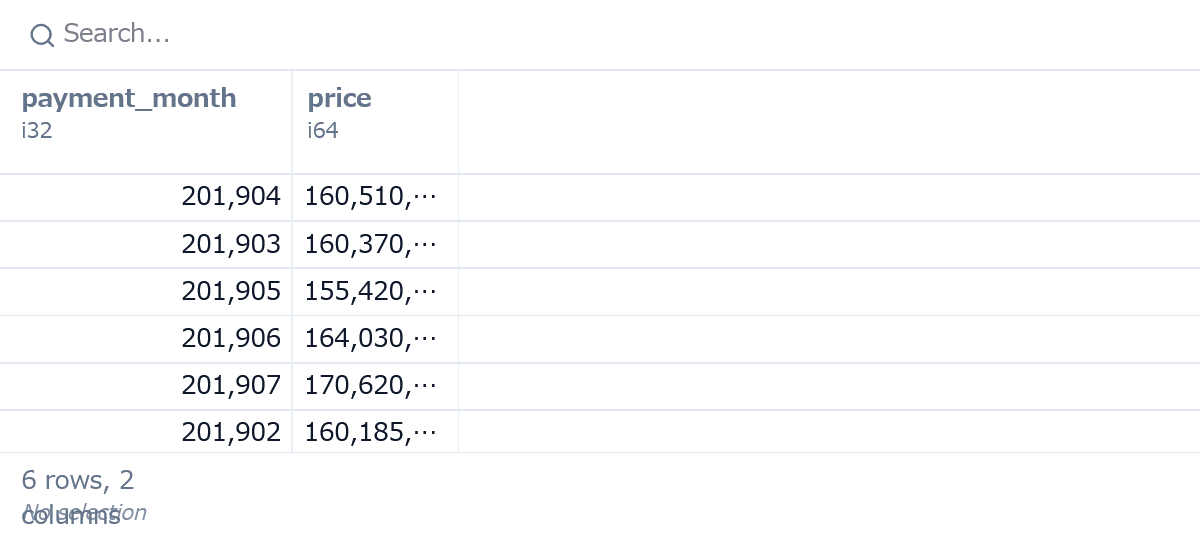

In [ ]:
join_data5.group_by("payment_month").agg([polars.sum("price")])

## ノック 9: 月別, 商品別でデータを集計してみよう

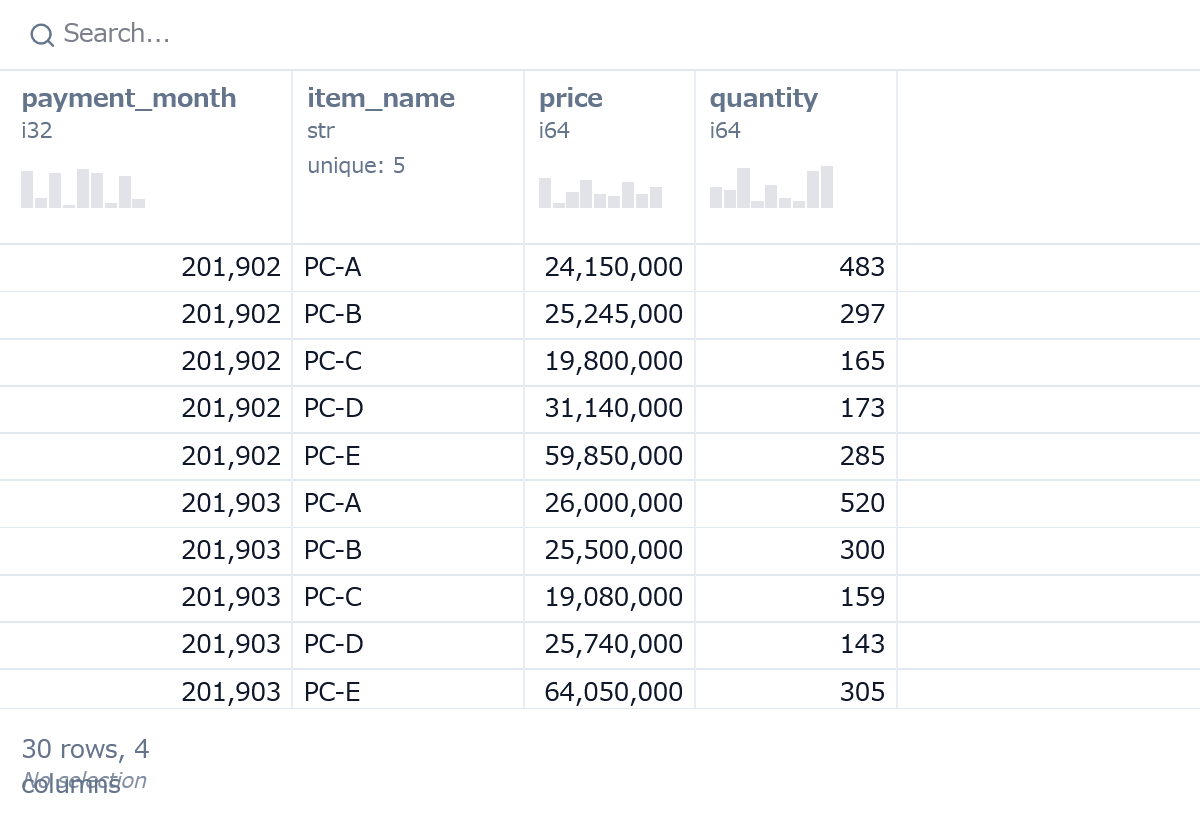

In [ ]:
join_data5.group_by(["payment_month", "item_name"]).agg(
    [polars.sum("price"), polars.sum("quantity")]
).sort(["payment_month", "item_name"])

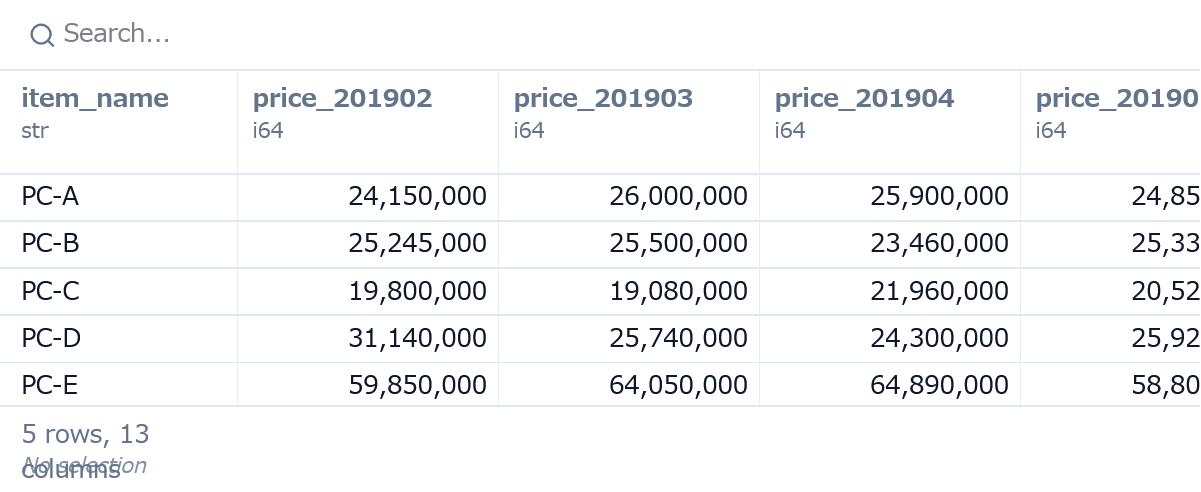

In [ ]:
join_data5.sort("payment_month").group_by(
    ["payment_month", "item_name"], maintain_order=True
).agg([polars.sum("price"), polars.sum("quantity")]).pivot(
    on="payment_month",
    index="item_name",
    values=["price", "quantity"],
).sort("item_name")

## ノック 10: 商品別の売上推移を可視化してみよう

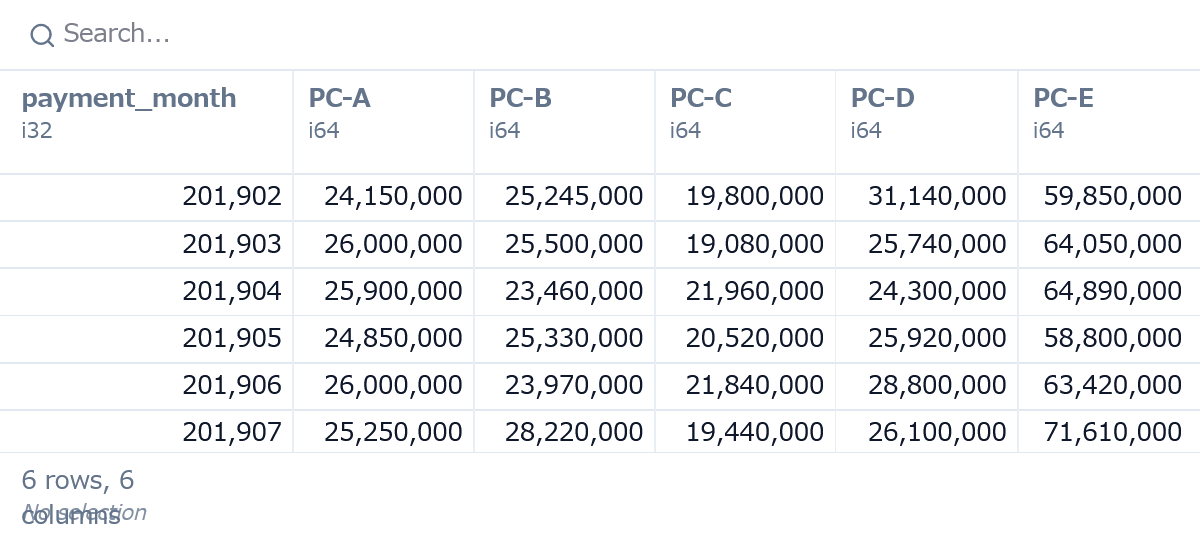

In [ ]:
graph_data = join_data5.sort("item_name").group_by(
    ["payment_month", "item_name"], maintain_order=True
).agg(polars.sum("price")).pivot(
    on="item_name",
    index="payment_month",
    values=["price"],
).sort("payment_month")

graph_data

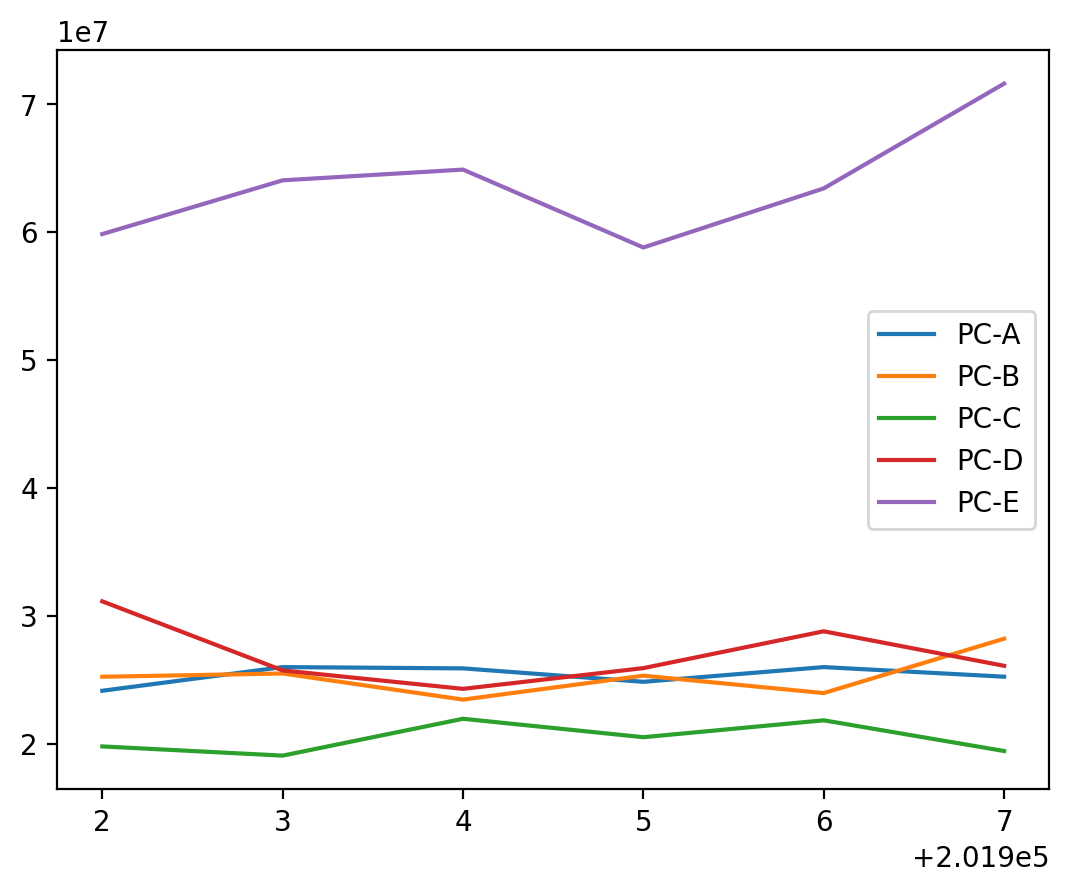

In [ ]:
for _col in graph_data.columns:
    if _col.startswith("PC-"):
        plt.plot(graph_data["payment_month"], graph_data[_col], label=_col)
plt.legend()

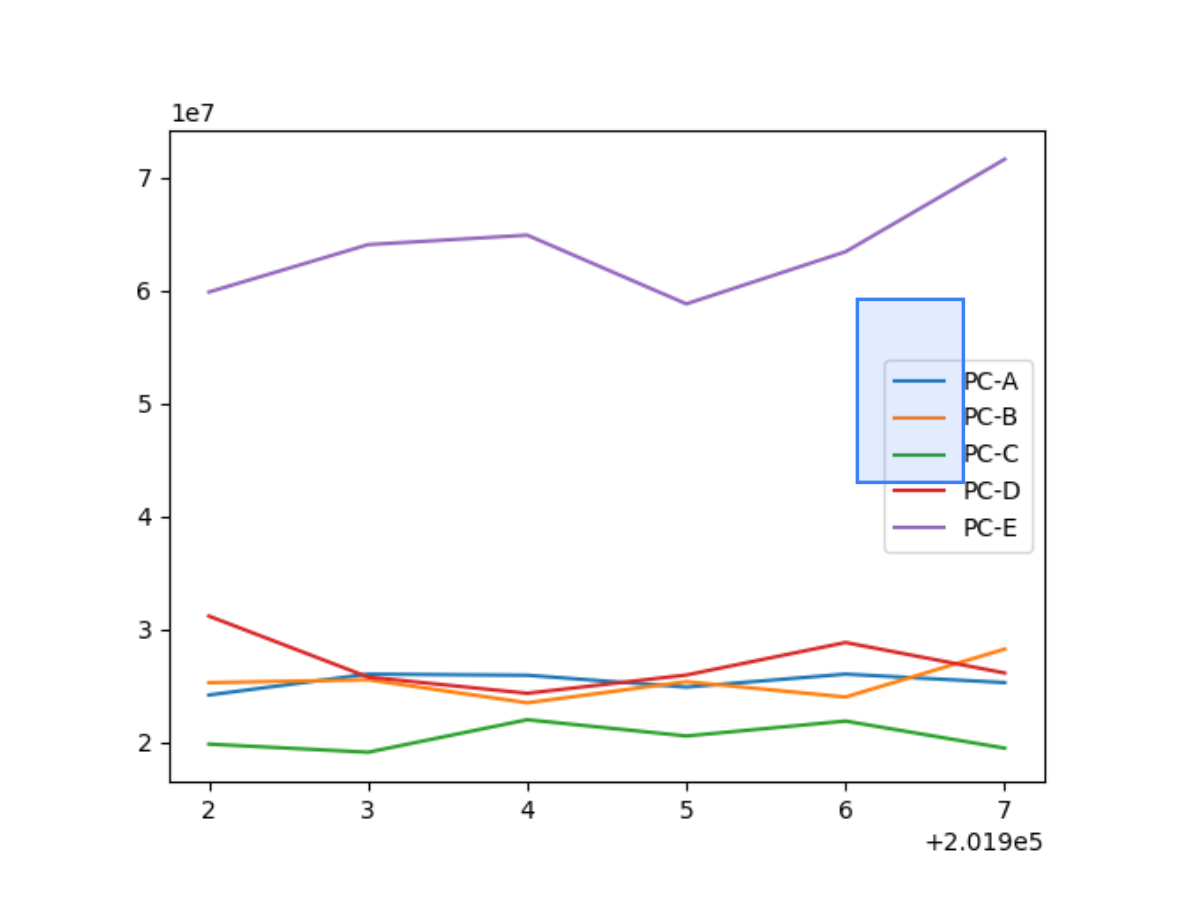

In [ ]:
for _col in graph_data.columns:
    if _col.startswith("PC-"):
        plt.plot(graph_data["payment_month"], graph_data[_col], label=_col)
plt.legend()
mo.ui.matplotlib(plt.gca())

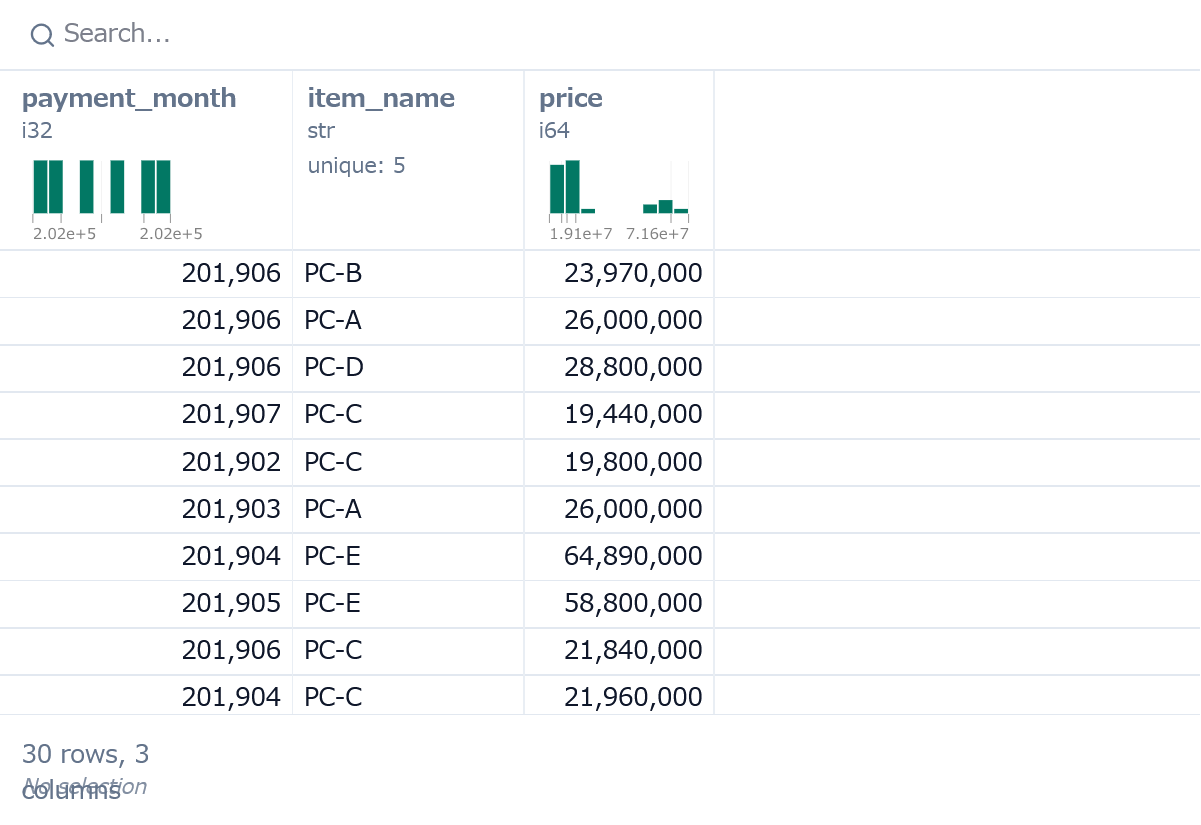

In [ ]:
# graph_data2 = join_data5.sort("item_name").group_by(
#     ["payment_month", "item_name"], maintain_order=True
# ).agg(polars.sum("price"))
graph_data2 = join_data5.group_by(
    ["payment_month", "item_name"]
).agg(polars.sum("price"))

graph_data2

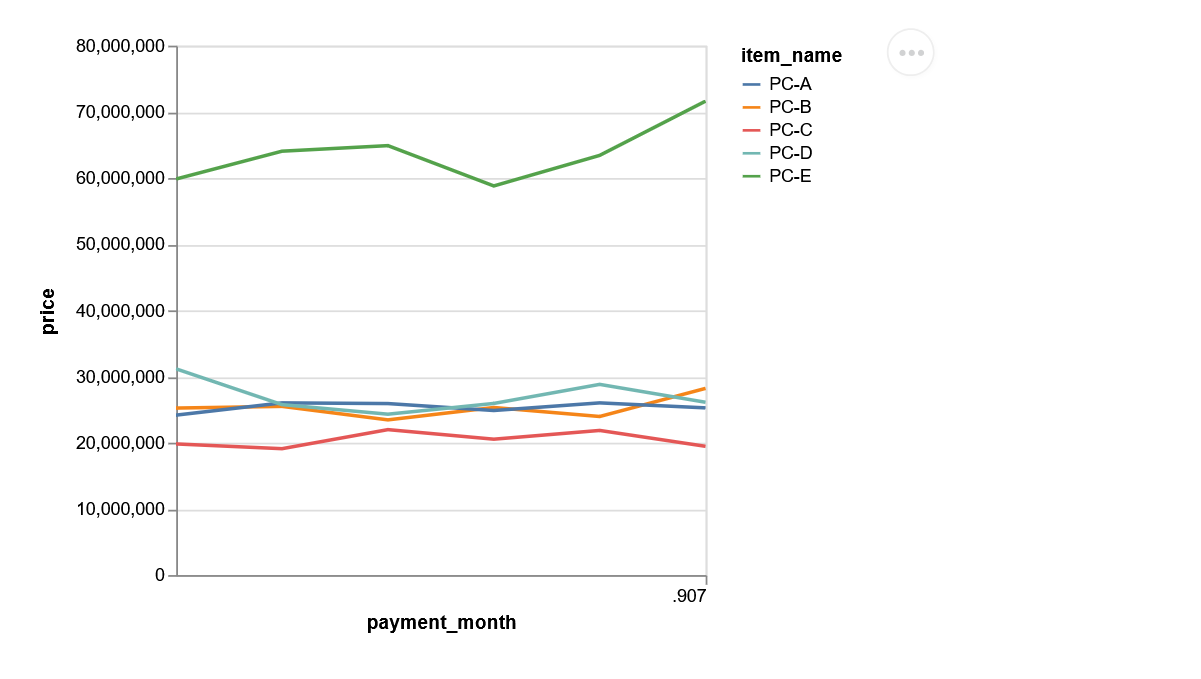

In [ ]:
altair.Chart(graph_data2).mark_line().encode(
    x="payment_month:T",
    y="price:Q",
    color="item_name:N"
)

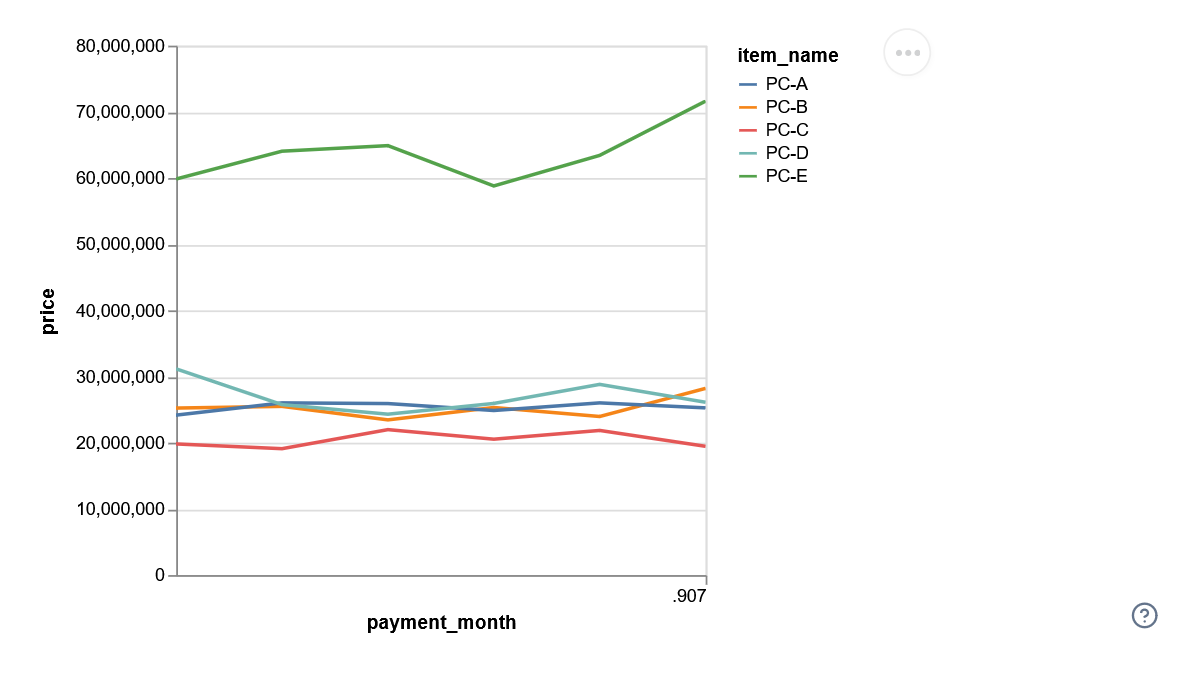

In [ ]:
mo.ui.altair_chart(altair.Chart(graph_data2).mark_line().encode(
    x="payment_month:T",
    y="price:Q",
    color="item_name:N"
))